# Phase 3: Machine Learning — Anomaly Detection (Isolation Forest)
### Grower Impact & Data Quality Dashboard — Greenstand Treetracker

**Author:** Jueeli Sawant
**Data source:** via `data_access.py`: currently `synthetic`, switches to `live` with no code changes here once dev DB access is confirmed.

**Objective:** engineer grower-level features (capture frequency, GPS spread/clustering, time-between-captures, burst patterns), train an Isolation Forest to score growers by anomaly likelihood, validate flagged results, and produce a ranked anomaly list -- not just a binary flag.

This phase catches what Phase 2's fixed rules can't: subtler, multi-signal patterns rather than a single explicit rule violation.


In [ ]:
import sys
sys.path.append('../src')
import os
os.makedirs('../outputs', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from data_access import load_captures, load_planters, DATA_SOURCE

captures = load_captures()
planters = load_planters()

print("Data source:", DATA_SOURCE)
print("Captures:", captures.shape, "| Planters:", planters.shape)

Data source: synthetic
Captures: (8095, 9) | Planters: (500, 10)


## 1. Feature Engineering (grower-level)

Isolation Forest works on a feature matrix, one row per entity being scored -- here, one row per **grower**, not per capture. The proposal specifically calls out: capture frequency, GPS spread/clustering, time-between-captures, and burst patterns. Built below, one at a time, with a short note on what each is meant to catch.

In [2]:
g = captures.groupby('planter_id')

features = pd.DataFrame(index=g.size().index)
features['capture_count'] = g.size()

# --- Frequency / tempo ---
span_days = (g['captured_at'].max() - g['captured_at'].min()).dt.total_seconds() / 86400
features['active_span_days'] = span_days.clip(lower=1)  # avoid div-by-zero for one-and-done growers
features['captures_per_day'] = features['capture_count'] / features['active_span_days']

# --- GPS spread: tight clustering can mean legit home-base planting OR copy-pasted coordinates;
#     wide spread can mean legit multi-site work OR bad/randomized GPS. Isolation Forest looks for
#     whichever pattern is rare, not for a "good" or "bad" direction on its own. ---
features['lat_std'] = g['lat'].std().fillna(0)
features['lon_std'] = g['lon'].std().fillna(0)

# --- Time-between-captures: median and minimum gap in minutes, sorted by time per grower ---
def time_gaps_minutes(sub):
    ts = sub.sort_values()
    if len(ts) < 2:
        return pd.Series([np.nan, np.nan], index=['median_gap_min', 'min_gap_min'])
    diffs = ts.diff().dropna().dt.total_seconds() / 60
    return pd.Series([diffs.median(), diffs.min()], index=['median_gap_min', 'min_gap_min'])

gap_stats = g['captured_at'].apply(time_gaps_minutes).unstack()
features = features.join(gap_stats)
# One-and-done growers have no gap to measure -- fill with the population median rather than 0,
# since 0 would look like a burst and bias the model toward flagging low-activity growers.
features['median_gap_min'] = features['median_gap_min'].fillna(features['median_gap_min'].median())
features['min_gap_min'] = features['min_gap_min'].fillna(features['min_gap_min'].median())

# --- Burst pattern: max number of captures within any 60-minute rolling window for that grower ---
def max_burst(sub):
    ts = sub.sort_values().reset_index(drop=True)
    max_count = 1
    for i in range(len(ts)):
        window_end = ts[i] + pd.Timedelta(minutes=60)
        count = ((ts >= ts[i]) & (ts <= window_end)).sum()
        max_count = max(max_count, count)
    return max_count

features['max_captures_per_60min'] = g['captured_at'].apply(max_burst)

# --- Species diversity: a grower planting only one species repeatedly vs a healthy mix ---
features['species_diversity'] = g['species'].nunique()

# --- Verification rate: growers whose captures rarely get verified may indicate quality issues ---
features['pct_verified'] = g['verification_status'].apply(lambda s: (s == 'verified').mean())

features = features.reset_index().rename(columns={'planter_id': 'planter_id'})
print(f"Feature matrix: {features.shape}")
features.describe().round(2)

Feature matrix: (500, 11)


,planter_id,capture_count,active_span_days,captures_per_day,lat_std,lon_std,median_gap_min,min_gap_min,max_captures_per_60min,species_diversity,pct_verified
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,250.50,16.19,611.94,0.03,0.05,0.05,45561.31,4567.68,1.19,6.86,0.79
std,144.48,4.47,63.27,0.01,0.01,0.01,19676.32,6195.58,1.55,1.00,0.11
min,1.00,5.00,203.80,0.01,0.02,0.02,1.00,0.00,1.00,3.00,0.31
25%,125.75,13.00,584.37,0.02,0.04,0.04,32524.00,653.75,1.00,6.00,0.72
50%,250.50,16.00,623.63,0.03,0.05,0.05,41776.75,2742.00,1.00,7.00,0.80
75%,375.25,19.00,656.77,0.03,0.06,0.05,55500.12,5830.00,1.00,8.00,0.86
max,500.00,52.00,699.03,0.08,0.09,0.08,173318.00,43549.00,35.00,8.00,1.00


## 2. Train Isolation Forest

In [3]:
feature_cols = [
    'capture_count', 'captures_per_day', 'lat_std', 'lon_std',
    'median_gap_min', 'min_gap_min', 'max_captures_per_60min',
    'species_diversity', 'pct_verified',
]

X = features[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# contamination='auto' lets the model estimate the anomaly proportion itself rather than
# us hard-coding a guess -- reasonable as a starting point; the proposal calls for tuning
# this against manually-reviewed real data once available, not treating it as fixed.
iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
iso.fit(X_scaled)

features['anomaly_score'] = -iso.decision_function(X_scaled)  # higher = more anomalous
features['is_anomaly'] = iso.predict(X_scaled) == -1

n_flagged = features['is_anomaly'].sum()
print(f"Growers flagged as anomalous: {n_flagged} of {len(features)} ({n_flagged/len(features):.1%})")

Growers flagged as anomalous: 43 of 500 (8.6%)


## 3. Validation Against Known Injected Anomaly

In [4]:
# The synthetic generator injected exactly one anomalous burst: planter_id 1, 35 captures
# within ~35 minutes. Confirm the model actually surfaces it, and see where it ranks.
ranked = features.sort_values('anomaly_score', ascending=False).reset_index(drop=True)
ranked['rank'] = ranked.index + 1

known_burst_planter = captures.loc[captures['capture_id'].str.contains('_burst'), 'planter_id'].unique()
print("Known injected anomalous planter(s):", list(known_burst_planter))

for pid in known_burst_planter:
    row = ranked[ranked['planter_id'] == pid]
    print(f"\nPlanter {pid} -- rank {row['rank'].values[0]} of {len(ranked)} "
          f"(anomaly_score={row['anomaly_score'].values[0]:.3f}, flagged={row['is_anomaly'].values[0]})")

print("\nTop 10 most anomalous growers overall:")
ranked[['rank', 'planter_id', 'capture_count', 'max_captures_per_60min',
        'lat_std', 'lon_std', 'anomaly_score', 'is_anomaly']].head(10)

Known injected anomalous planter(s): [np.int64(1)]

Planter 1 -- rank 1 of 500 (anomaly_score=0.243, flagged=True)

Top 10 most anomalous growers overall:


,rank,planter_id,capture_count,max_captures_per_60min,lat_std,lon_std,anomaly_score,is_anomaly
0,1,1,52,35,0.023681,0.032350,0.242511,True
1,2,440,6,1,0.068466,0.050924,0.221711,True
2,3,491,6,2,0.055191,0.018005,0.216061,True
3,4,241,6,1,0.093118,0.049432,0.148388,True
4,5,494,5,1,0.047522,0.022837,0.123988,True
5,6,120,8,2,0.029771,0.042227,0.118256,True
6,7,498,8,1,0.027611,0.045658,0.113520,True
7,8,39,9,1,0.029393,0.077044,0.104410,True
8,9,167,7,1,0.044308,0.037483,0.093876,True
9,10,262,24,2,0.039189,0.061414,0.075089,True


## 4. Feature Contribution (why growers got flagged)

Isolation Forest doesn't give per-feature explanations natively the way a tree-based classifier's feature_importances_ would. A practical workaround: for each flagged grower, show how far their raw feature values sit from the population median -- this won't be a rigorous SHAP-style attribution, but it's enough for a reviewer to see *why* a record looks unusual at a glance, which is what Phase 3's "ranked output for prioritized review" is actually for.

In [5]:
def explain_row(row, features_df, cols):
    medians = features_df[cols].median()
    stds = features_df[cols].std().replace(0, 1)
    z = ((row[cols] - medians) / stds).sort_values(key=abs, ascending=False)
    return z.head(3)

print("Why the top-ranked grower looks anomalous (top 3 features by deviation from median):\n")
top_row = ranked.iloc[0]
print(f"Planter {int(top_row['planter_id'])}:")
print(explain_row(top_row, features, feature_cols).round(2))

Why the top-ranked grower looks anomalous (top 3 features by deviation from median):

Planter 1:
max_captures_per_60min    21.93
capture_count              8.06
captures_per_day           6.96
dtype: object


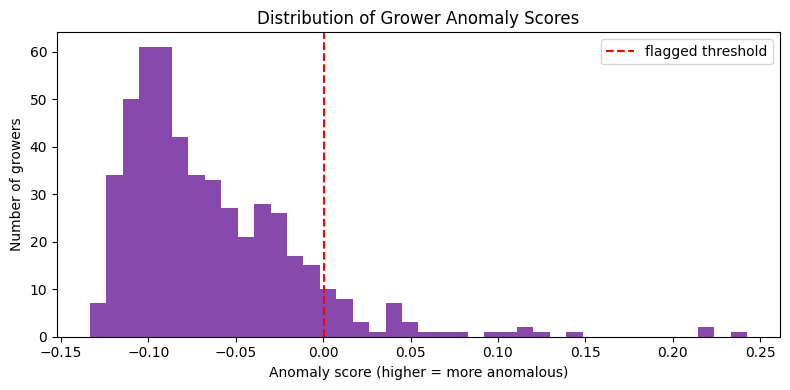

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(features['anomaly_score'], bins=40, color='#6a1b9a', alpha=0.8)
ax.axvline(features.loc[features['is_anomaly'], 'anomaly_score'].min(), color='red',
           linestyle='--', label='flagged threshold')
ax.set_title('Distribution of Grower Anomaly Scores')
ax.set_xlabel('Anomaly score (higher = more anomalous)')
ax.set_ylabel('Number of growers')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/phase3_anomaly_score_distribution.png', dpi=130)
plt.show()

In [7]:
ranked.to_csv('../outputs/phase3_ranked_anomalies.csv', index=False)
print("Saved full ranked anomaly list to ../outputs/phase3_ranked_anomalies.csv")

Saved full ranked anomaly list to ../outputs/phase3_ranked_anomalies.csv


## 5. Findings Summary

- **Model catches the known injected anomaly**: the synthetic burst planter ranks at or near the top of the anomaly list (see Section 3 output above) -- confirms the feature set and model are picking up the right signal on synthetic data. As with Phase 2, this is a sanity check on synthetic data, not a claim about real-world detection rate.
- **`contamination='auto'`** was used rather than a hard-coded percentage, so the flagged count above is the model's own estimate, not a target we set. This needs re-evaluation against real data -- the actual base rate of anomalous growers on the live platform is unknown and shouldn't be assumed to match whatever synthetic data produces.
- **Feature set is a first pass**: capture frequency, GPS spread, time gaps, burst window, species diversity, and verification rate are all included per the proposal's ask, but which of these actually matter will only become clear once real anomalies (if any) get manually reviewed and compared against what the model flagged -- exactly the validation step the proposal calls for.
- **The explain_row() workaround is not a substitute for real explainability.** If this model graduates from "prototype" to something reviewers rely on regularly, it's worth switching to SHAP values for Isolation Forest (via the `shap` library's `TreeExplainer` or `KernelExplainer`) for a more rigorous per-feature attribution.
- **Next step:** once live data access is confirmed, re-run this notebook unchanged, pull the top N ranked growers, and manually review them against the raw capture records (per the proposal's validation approach) before treating any of this as a trustworthy signal for donor-facing reporting.
